Author:  
Manuel Eugenio Morocho Cayamcela, PhD

# Workshop
# **The future of Data Science** 

En esta actividad, se presenta el concepto de agrupamiento (clustering) utilizando un ejemplo relacionado con la base de datos `mall_customers.csv`, que presenta datos de clientes de un centro comercial y una variable que representa su comportamiento de compra.

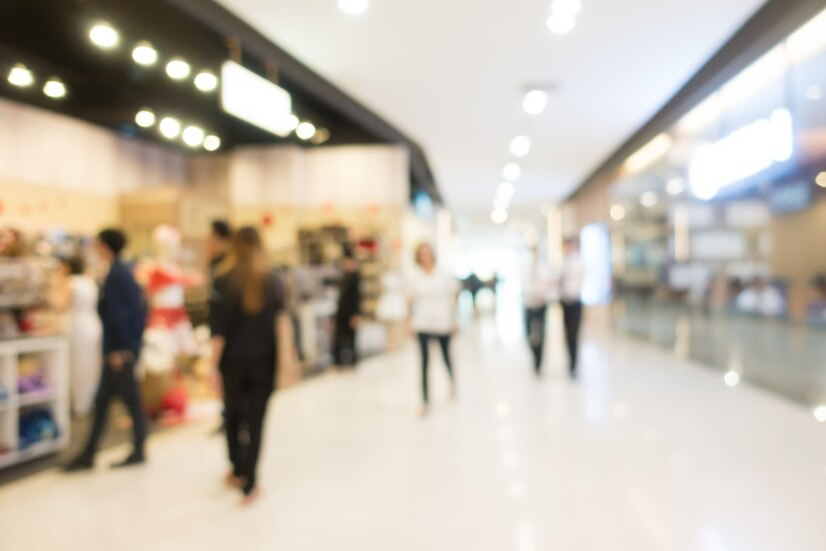

El conjunto de datos `mall_customers.csv` tiene las siguientes variables:

1. `CustomerID`: Un identificador único para cada cliente. Es un número entero que se incrementa en 1 para cada cliente. 

2. `Gender`: El género del cliente. Es una variable categórica con dos posibles valores: 'Male' y 'Female'.

3. `Age`: La edad del cliente. Es una variable numérica.

4. `Annual Income (k$)`: El ingreso anual del cliente, en miles de dólares. Es una variable numérica.

5. `Spending Score (1-100)`: La puntuación de gasto del cliente, en una escala de 1 a 100. Es una variable numérica. Esta puntuación es un indicador de cuánto gasta el cliente o de su comportamiento de compra.

## **1. The Data Engineer Job:**

#### Importamos los paquetes necesarios

In [1]:
# Instalamos los paquetes necesarios
%pip install scikit-learn pandas matplotlib seaborn
%matplotlib inline

# Importamos los paquetes necesarios
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Cargamos la base de datos

In [2]:
# Cargamos la base de datos 'mall_customers.csv' desde GitHub
clientes = pd.read_csv('https://raw.githubusercontent.com/eugeniomorocho/theFutureOfDS/refs/heads/main/mall_customers.csv')

# Visualizamos los primeros registros
clientes.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


#### Análisis exploratorio de datos (EDA)

In [3]:
# Usamos la función info() para ver el tipo de datos y la cantidad de registros
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# Usamos la función describe() para ver las estadísticas de los datos
clientes.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


array([[<Axes: title={'center': 'CustomerID'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Annual Income (k$)'}>,
        <Axes: title={'center': 'Spending Score (1-100)'}>]], dtype=object)

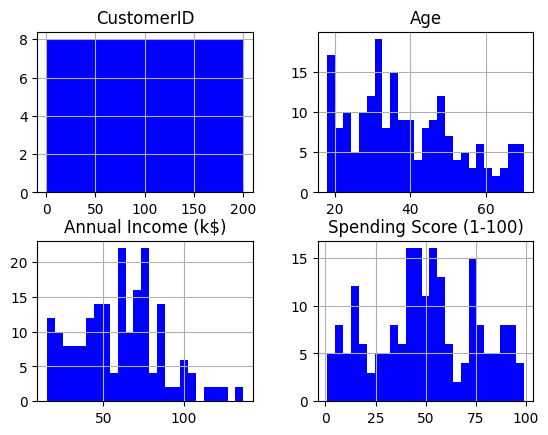

In [5]:
# Visualizamos el histograma de las variables
clientes.hist(bins=25, color='blue')

#### Eliminamos columnas que no aportan información útil para el análisis

La columna `CustomerID` es un identificador único para cada cliente. En la mayoría de los casos, este tipo de identificadores no aporta información útil para el análisis de los datos o para la construcción de modelos de data mining, ya que no tiene relación con las otras variables. Por lo tanto, es común eliminar esta columna antes de realizar el análisis.



El método `drop` de pandas elimina la columna especificada (`'CustomerID'`) del DataFrame. El argumento `axis=1` indica que queremos eliminar una columna (en lugar de una fila). El DataFrame resultante se guarda de nuevo en la variable `clientes`.

In [6]:
# Eliminamos la columna 'CustomerID'
clientes = clientes.drop('CustomerID', axis=1)
clientes.head(10)

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
5,Female,22,17,76
6,Female,35,18,6
7,Female,23,18,94
8,Male,64,19,3
9,Female,30,19,72


#### Codificamos la columna categórica 'Gender'

Utilizamos el método `replace` de pandas para reemplazar los valores en la columna 'Gender' del DataFrame 'clientes'.

- `clientes['Gender']`: Selecciona la columna 'Gender' del DataFrame 'clientes'.

- `replace({'Female': 0, 'Male': 1})`: Este método reemplaza los valores en la columna según el mapeo proporcionado. En este caso, está reemplazando 'Female' con 0 y 'Male' con 1. Esto se conoce como codificación de etiquetas o "label encoding".

El propósito de este código es convertir la variable categórica 'Gender' en una variable numérica, lo que nos será útil para calcular la correlación de variables. 

In [7]:
# Codificamos la variable 'Gender'
clientes['Gender'] = clientes['Gender'].replace({'Female': 0, 'Male': 1})
clientes.head(10)

/var/folders/8j/f0xtldm91_1c2bpdr69fxgzw0000gn/T/ipykernel_4980/1306256639.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clientes['Gender'] = clientes['Gender'].replace({'Female': 0, 'Male': 1})


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40
5,0,22,17,76
6,0,35,18,6
7,0,23,18,94
8,1,64,19,3
9,0,30,19,72


## **2. The Data Scientist Job:**

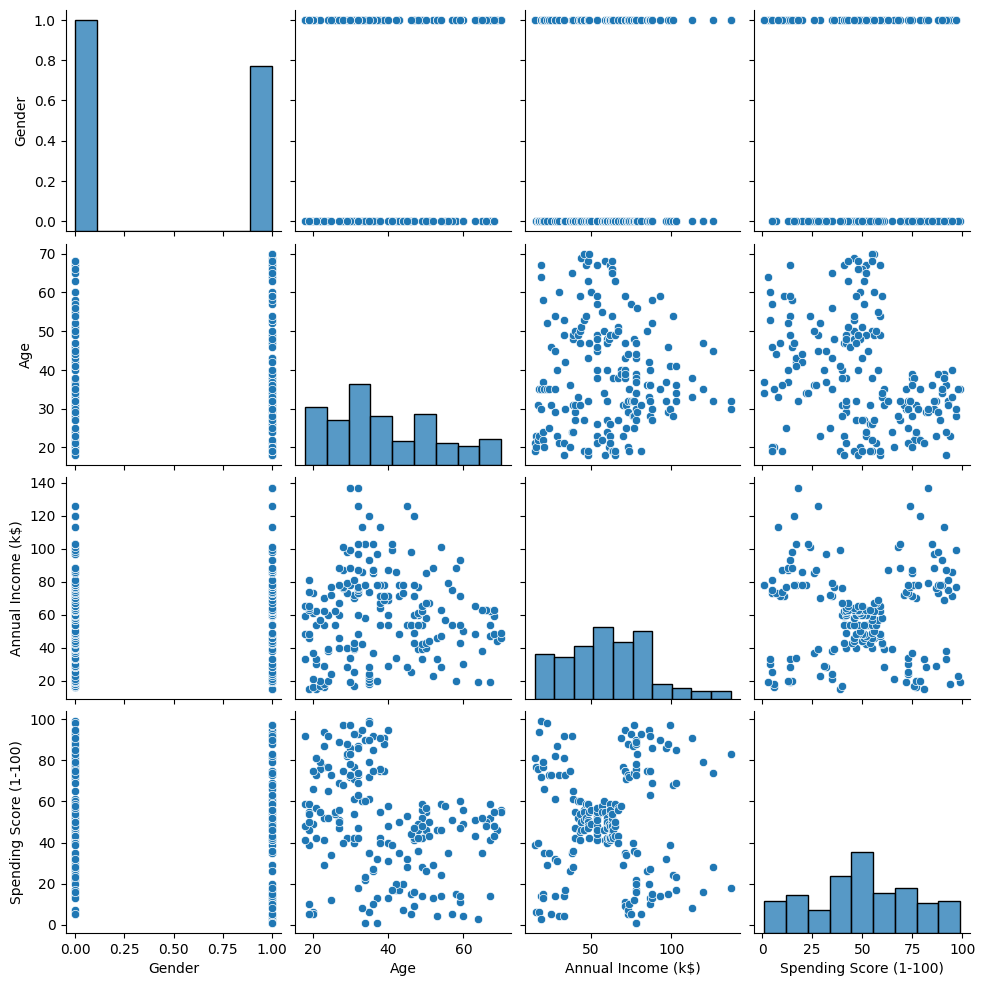

In [8]:
# Visualizamos un gráfico de dispersión entre todas las variables
sns.pairplot(clientes)

#### Creamos un nuevo DataFrame aislando las variables 'Annual Income (k$)' y 'Spending Score (1-100)'

El gráfico de dispersión entre 'Annual Income (k$)' y 'Spending Score (1-100)' revela agrupaciones visibles de datos, lo que sugiere que hay grupos de clientes con comportamientos de gasto similares en relación con sus ingresos anuales.

Creamos un nuevo DataFrame que contenga solo estas dos variables para analizar más a fondo estas agrupaciones y aplicar técnicas de clustering para identificar y definir estos grupos de manera más formal.

Esto puede proporcionar información valiosa para la estrategia de marketing, ya que permite segmentar a los clientes en función de su comportamiento de gasto en relación con sus ingresos, lo que a su vez puede informar decisiones sobre la orientación de las ofertas y promociones, la personalización de la comunicación con los clientes, y más.

In [11]:
# Instala ipywidgets para los widgets interactivos
%pip install ipywidgets

# Crea un reporte de perfiles de los datos (usando ydata-profiling)
%pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(clientes, title="Reporte de Perfil de Clientes del Mall", explorative=True)
profile.to_notebook_iframe()
#profile.to_file("reporte_clientes_mall.html")

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Render HTML: 100%|██████████| 1/1 [00:00<00:00,  1.03it/s]


In [11]:
# Creamos un DataFrame solamente con las columnas 'Age' y 'Annual Income(k$)'
income_spending = clientes[['Annual Income (k$)', 'Spending Score (1-100)']]
income_spending.head(10)

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
5,17,76
6,18,6
7,18,94
8,19,3
9,19,72


#### Graficamos la distribución de las variables 'Age' y 'Annual Income (k$)'

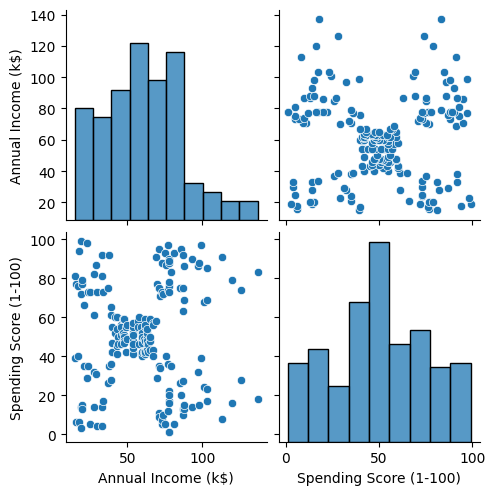

In [12]:
# Graficamos la distribución de income_spending
sns.pairplot(income_spending)

#### Agrupamos el DataFrame 'income_spending' usando el algoritmo KMeans

Usamos un agrupamiento `KMeans` en el DataFrame `income_spending` para encontrar 2 clusters utilizando el algoritmo KMeans, y luego añadimos las etiquetas de los clusters a los datos.

- `modelo_kmeans = KMeans(n_clusters=2)`: Esta línea crea una instancia del modelo KMeans con 2 clusters. El número de clusters es un parámetro que se debe especificar.

- `modelo_kmeans.fit(income_spending)`: Esta línea ajusta el modelo a los datos de `income_spending`. El modelo KMeans intentará encontrar los centros de los clusters que minimizan la varianza dentro de cada cluster.

- `income_spending['Cluster'] = modelo_kmeans.labels_`: Después de ajustar el modelo, puedes obtener las etiquetas de los clusters para cada punto de datos utilizando el atributo `labels_` del modelo. Esta línea añade las etiquetas de los clusters como una nueva columna en el DataFrame `income_spending`.

- `income_spending.head(10)`: Esta línea muestra las primeras 10 filas del DataFrame `income_spending`, que ahora incluye la columna 'Cluster'.

In [13]:
# Instanciamos el modelo KMeans
modelo_kmeans = KMeans(n_clusters=2)

# Ajustamos el modelo a los datos
modelo_kmeans.fit(income_spending)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [14]:
# Duplicamos la base de datos 'income_spending' para no modificar la original y agregar los clusters
income_spending_cluster = income_spending.copy()

# Obtenemos las etiquetas de los clusters asignados a cada cliente
income_spending_cluster['Cluster'] = modelo_kmeans.labels_

# Visualizamos los primeros registros de 'income_spending_cluster'
income_spending_cluster.head(10)

,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,0
1,15,81,0
2,16,6,0
3,16,77,0
4,17,40,0
5,17,76,0
6,18,6,0
7,18,94,1
8,19,3,0
9,19,72,0


In [15]:
income_spending_cluster.tail(10)

,Annual Income (k$),Spending Score (1-100),Cluster
190,103,23,0
191,103,69,1
192,113,8,0
193,113,91,1
194,120,16,0
195,120,79,1
196,126,28,0
197,126,74,1
198,137,18,0
199,137,83,1


Creamos un gráfico de pares de las variables de `income_spending`, coloreando los puntos de acuerdo con los clusters identificados por el algoritmo KMeans. Esto nos ayuda a visualizar cómo se distribuyen los clusters en el espacio de las variables.

- `sns.pairplot(income_spending)`: Esta función crea un gráfico de pares de todas las variables en el DataFrame `income_spending`. Un gráfico de pares muestra la relación entre cada par de variables en un conjunto de datos.

- `hue='Cluster'`: Este argumento indica que los puntos en el gráfico deben ser coloreados de acuerdo con la columna 'Cluster'. Esto permite visualizar cómo se distribuyen los clusters en cada par de variables.

- `palette='viridis'`: Este argumento establece la paleta de colores a usar para los diferentes clusters. 'viridis' es una paleta de colores perceptualmente uniforme que es fácil de interpretar.

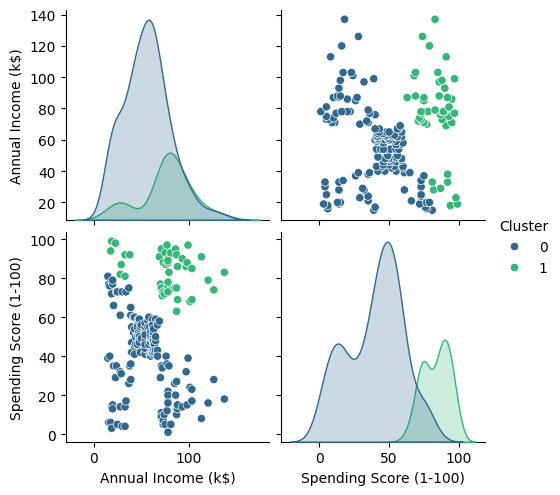

In [16]:
# Visualizamos los clusters generados por el modelo KMeans
sns.pairplot(income_spending_cluster, hue='Cluster', palette='viridis')

In [17]:
# Encontramos la inercia del modelo KMeans
inercia = modelo_kmeans.inertia_
inercia

185917.14253928524

#### Evaluamos el mejor valor de $k$ con el método del codo

Vemos que posiblemente 2 no sea el valor óptimo de $k$ que buscamos. Intentemos encontrar el mejor valor de $k$ utilizando el método del codo. 

La **inercia** es una métrica que mide **qué tan cerca están los puntos de datos a los centroides de sus respectivos clusters**.

La **inercia** se define como la **suma de las distancias cuadradas** entre cada punto y su centroide asignado:

$ \text{Inercia} = \sum_{i=1}^{n} \min_{c \in \text{centroides}} ||x_i - c||^2 $

- $ x_i $: punto de datos.
- $ c $: centroide del cluster asignado.
- $ ||x_i - c||^2 $: distancia euclidiana al cuadrado.


Este método implica ejecutar el algoritmo de agrupamiento KMeans para un rango de valores de $k$ y luego trazar el número de clusters contra la suma de las distancias al cuadrado dentro de cada cluster. El "codo" en esta trama, es decir, el punto de inflexión donde la tasa de disminución se vuelve significativamente menor, puede indicar un buen valor de $k$.

El método del codo se usa para determinar el número óptimo de grupos (clusters) para el algoritmo KMeans.

1. `ks = range(1, 10)`: Aquí se define un rango de números del 1 al 9. Estos representan los posibles números de clusters que se probarán en el algoritmo KMeans.

2. `inercias = []`: Se crea una lista vacía llamada `inercias` para almacenar los valores de inercia para cada número de clusters.

3. Luego, se realiza un bucle sobre cada número en el rango `ks`:

   - `model = KMeans(n_clusters=k)`: Se crea una instancia del algoritmo KMeans con `k` clusters. El parámetro `random_state` es utilizado para controlar la aleatoriedad en la inicialización del algoritmo y es útil para asegurar que los resultados sean reproducibles.
   
   - `model.fit(samples)`: Se ajusta el modelo a los datos contenidos en `samples`.
   
   - `inercias.append(model.inertia_)`: Se añade el valor de la inercia del modelo a la lista `inercias`. La inercia es una medida de cuán dispersos están los clusters, y se busca minimizarla.

4. Finalmente, se grafican los valores de inercia en función del número de clusters:

   - `plt.plot(ks, inercias, marker='+', linewidth=0.5, markersize=5)`: Se crea un gráfico de línea entre `ks` e `inercias`. El argumento `marker='+'` especifica que se deben usar cruces (`+`) como marcadores en el gráfico. El argumento `linewidth=0.5` establece el ancho de la línea del gráfico a 0.5, y el argumento `markersize=5` establece el tamaño de los marcadores a 5.
   
   - `plt.xlabel('Número de clusters, k')` y `plt.ylabel('Inercia')`: Se establecen las etiquetas de los ejes x e y.
   
   - `plt.xticks(ks)`: Se establecen las marcas del eje x para que coincidan con los números de clusters.
   
   - `plt.show()`: Se muestra el gráfico.

El punto en el que la línea del gráfico se dobla (como un "codo") suele considerarse un buen indicador del número óptimo de clusters.

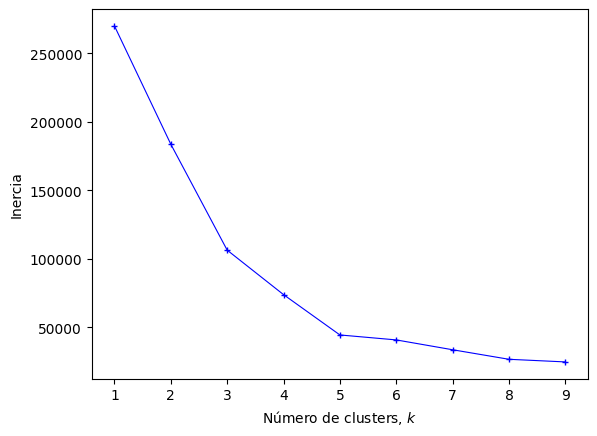

In [18]:
# Definimos un rango de números del 1 al 9 para representar los posibles números de clusters
ks = range(1, 10)
# Creamos una lista vacía para almacenar los valores de inercia para cada número de clusters
inercias = []

# Iteramos sobre cada número en el rango ks
for k in ks:
    # Creamos una instancia del algoritmo KMeans con k clusters
    model = KMeans(n_clusters=k, random_state=42)
    # Ajustamos el modelo a los datos contenidos en income_spending
    model.fit(income_spending)
    # Añadimos el valor de la inercia del modelo a la lista inercias
    inercias.append(model.inertia_)
    
# Graficamos los valores de inercia en función del número de clusters
plt.plot(ks, inercias, marker='+', linewidth=0.8, markersize=5, color='blue')
# Establecemos la etiqueta del eje x
plt.xlabel('Número de clusters, $k$')
# Establecemos la etiqueta del eje y
plt.ylabel('Inercia')
# Establecemos las marcas del eje x para que coincidan con los números de clusters
plt.xticks(ks)
# Mostramos el gráfico
plt.show()


#### Ajustamos el modelo con el nuevo valor de $k$ y visualizamos los clusters

Observamos que el punto de inflexión ocurre en $k$ = 5, entonces es razonable seleccionar 5 como el nuevo valor óptimo para $k$.

Ahora volvemos a ejecutar el algoritmo KMeans con $k$ = 5 y observamos cómo cambian los clusters. Esto nos proporciona una segmentación más precisa de los clientes basada en sus ingresos anuales y puntuaciones de gasto.

In [19]:
# Instanciamos el modelo KMeans
modelo_kmeans = KMeans(n_clusters=5)

# Ajustamos el modelo a los datos
modelo_kmeans.fit(income_spending)

# Obtenemos las etiquetas de los clusters asignados a cada cliente
income_spending['Cluster'] = modelo_kmeans.labels_
income_spending.head(10)

/var/folders/8j/f0xtldm91_1c2bpdr69fxgzw0000gn/T/ipykernel_11553/3789396128.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  income_spending['Cluster'] = modelo_kmeans.labels_


,Annual Income (k$),Spending Score (1-100),Cluster
0,15,39,4
1,15,81,3
2,16,6,4
3,16,77,3
4,17,40,4
5,17,76,3
6,18,6,4
7,18,94,3
8,19,3,4
9,19,72,3


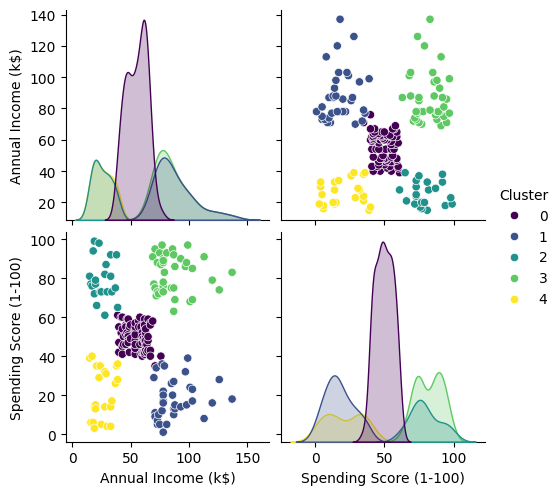

In [18]:
# Visualizamos los clusters
sns.pairplot(income_spending, hue='Cluster', palette='viridis')

#### Hacemos predicciones con los datos de un cliente nuevo

Finalmente, podemos usar el modelo KMeans que se ajustó anteriormente para predecir a qué cluster pertenece un nuevo cliente basándonos en sus características.

- `cliente_nuevo = [ , ]`: Esta línea crea una lista que representa los datos de un nuevo cliente. Los valores en la lista corresponden a las características del cliente (ingresos anuales, puntuación de gasto).

- `cluster_nuevo = modelo_kmeans.predict([cliente_nuevo])`: Esta línea utiliza el método `predict` del modelo KMeans para predecir a qué cluster pertenece el nuevo cliente. El método `predict` toma una lista de listas como entrada, donde cada lista interna representa los datos de un cliente. En este caso, solo hay un cliente, por lo que la entrada es `[cliente_nuevo]`.

- `print('El nuevo cliente pertenece al cluster:', cluster_nuevo)`: Esta línea imprime el cluster al que pertenece el nuevo cliente. El método `predict` devuelve una lista de etiquetas de cluster, una para cada cliente en la entrada. En este caso, solo hay un cliente, por lo que `cluster_nuevo` es una lista con un solo elemento.

In [20]:
# Creamos los datos de un nuevo cliente (ingresos anuales, puntuación de gasto) para hacer una predicción
cliente_nuevo = [40, 60]

# Hacemos una predicción con el modelo KMeans para el nuevo cliente
cluster_nuevo = modelo_kmeans.predict([cliente_nuevo])
print('El nuevo cliente pertenece al cluster:', cluster_nuevo)

El nuevo cliente pertenece al cluster: [1]


/Users/eugenio/Documents/Notebooks_ArtificialIntelligence/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


#### Visualizamos al cliente nuevo en los agrupamientos

Creamos un gráfico de dispersión de los ingresos anuales frente a la puntuación de gasto de los clientes, coloreando los puntos de acuerdo con su asignación de cluster, y añadiendo el nuevo cliente al gráfico.

- `plt.scatter(income_spending['Annual Income (k$)'], income_spending['Spending Score (1-100)'], c=income_spending['Cluster'], cmap='viridis')`: Esta línea crea un gráfico de dispersión de los ingresos anuales frente a la puntuación de gasto de los clientes existentes. Los puntos se colorean de acuerdo con su asignación de cluster.

- `plt.scatter(cliente_nuevo[0], cliente_nuevo[1], c='red', marker='x', s=100, label='Cliente Nuevo')`: Esta línea añade el nuevo cliente al gráfico de dispersión. El nuevo cliente se representa como una 'x' roja.

- `plt.xlabel('Annual Income (k$)')` y `plt.ylabel('Spending Score (1-100)')`: Estas líneas establecen las etiquetas de los ejes x e y del gráfico.

- `plt.legend()`: Esta línea añade una leyenda al gráfico.

- `plt.show()`: Esta línea muestra el gráfico.

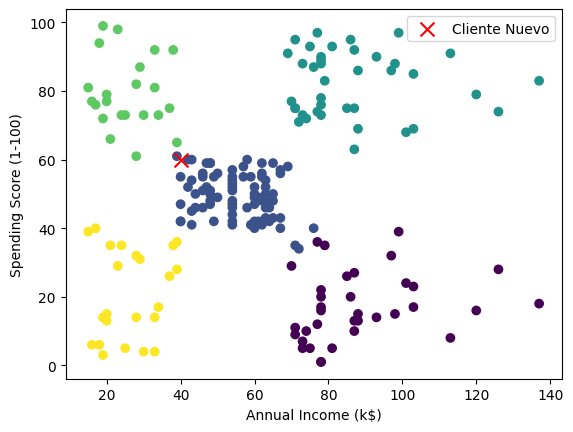

In [21]:
# Visualizamos los datos del cliente nuevo en el espacio de las variables 'Annual Income (k$)' y 'Spending Score (1-100)'
plt.scatter(income_spending['Annual Income (k$)'], income_spending['Spending Score (1-100)'], c=income_spending['Cluster'], cmap='viridis')
plt.scatter(cliente_nuevo[0], cliente_nuevo[1], c='red', marker='x', s=100, label='Cliente Nuevo')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

## **3. The Data Analyst Job:**

Al agrupar los clientes en 5 grupos utilizando las variables `Spending Score` y `Annual Income`, podemos obtener información valiosa para un reporte de inteligencia de negocios. Aquí hay algunas posibilidades:

1. **Segmentación de clientes**: Los grupos pueden representar diferentes segmentos de clientes. Por ejemplo, el grupo superior derecho consistuye clientes con ingresos altos y puntuaciones de gasto altas, lo que podría representar a los clientes que generan la mayor parte de los ingresos. Estos segmentos representan una oportunidad para dirigir estrategias de marketing más agresivas o lanzar productos premium.

2. **Oportunidades de marketing y ventas**: Si un grupo de clientes tiene ingresos altos pero puntuaciones de gasto bajas, esto podría indicar una oportunidad para aumentar las ventas a través de campañas de marketing dirigidas.

3. **Planificación de productos y servicios**: Si un grupo de clientes tiene ingresos bajos y puntuaciones de gasto altas, esto podría sugerir que estos clientes valoran los productos o servicios a pesar de sus ingresos más bajos. Esto podría ser útil para la planificación de nuevos productos de fidelización de clientes. 

4. **Estrategia de precios**: Los grupos con diferentes niveles de ingresos y puntuaciones de gasto pueden requerir diferentes estrategias de precios. Por ejemplo, los clientes con ingresos bajos y puntuaciones de gasto bajas pueden no estar dispuestos a pagar más por productos o servicios premium.

También se puede observar un segmento tiene un equilibrio entre ingresos y gastos.

Estas son solo ejemplos de posibilidades para esta base de datos en específico. La interpretación de los grupos depende del contexto del negocio y de los datos. Al incluir estas y otras conclusiones en un informe de inteligencia de negocios, se puede proporcionar información accionable que pueden guiar las decisiones estratégicas de la empresa para maximizar el valor del cliente y mejorar el rendimiento comercial.

A través de este análisis, hemos logrado segmentar nuestros clientes en cinco grupos distintos utilizando las variables `Spending Score` y `Annual Income`. Esta segmentación nos permite entender mejor las necesidades y comportamientos de nuestros clientes, y nos proporciona la capacidad de personalizar nuestras ofertas y comunicaciones de marketing para cada segmento.

Hemos identificado oportunidades para aumentar las ventas, particularmente en el segmento de clientes con ingresos altos pero puntuaciones de gasto bajas. Este grupo podría ser un objetivo ideal para campañas de marketing dirigidas.

Además, los diferentes segmentos de clientes pueden requerir diferentes estrategias de precios. Podríamos considerar la posibilidad de ofrecer productos o servicios premium a un precio más alto para el segmento de clientes con ingresos altos y puntuaciones de gasto altas.

## **The rise of GenAI: What changes for Modern Data Science?**

Primero, necesitarás instalar la biblioteca `openai` de Python. Puedes hacerlo ejecutando el siguiente comando en una celda de tu Jupyter Notebook:

In [13]:
%pip install --upgrade openai
from openai import OpenAI


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Antes de poder usar la API de OpenAI, necesitarás una clave de API. Puedes obtener una registrándote en el [sitio web de OpenAI](https://openai.com/signup/). Una vez que tengas tu clave de API, puedes configurarla de la siguiente manera:

In [ ]:
import os

# Reemplaza 'tu-clave-de-api' con tu clave de API real
os.environ['OPENAI_API_KEY'] = 'tu-clave-de-api'

# Cargamos la clave de API de OpenAI desde la variable de entorno
#api_key = os.getenv('OPENAI_API_KEY')
#print(api_key)  # solo para probar que la cargó

**Nota:** Recuerda reemplazar `'tu-clave-de-api'` con tu clave de API real. Además, ten en cuenta que debes mantener tu clave de API segura y no compartirla con nadie.

### Preguntando a un DataFrame de Pandas

In [15]:
# Convertir la tabla a un string
df_string = income_spending.to_string()

NameError: name 'income_spending' is not defined

In [30]:
#### DATA ENGINEER ####
#question = "Limpia la base de datos de clientes eliminando columnas innecesarias y corrige los tipos de datos."

#### DATA SCIENTIST ####
#question = "Resume visualmente los segmentos con gráficos si es posible (por ejemplo, scatter plots de Income vs Spending Score con clusters)."
question = "¿Cómo puedo segmentar de manera efectiva a estos clientes? Usa python y explica por qué eliges ese método. Describe cuántos segmentos o clusters se identifican y las características de cada uno (edad, ingreso, gasto, etc.)."

#### DATA ANALYST ####
#question = "¿Qué estrategias específicas de marketing recomendarías para cada segmento de clientes considerando su edad?"
#question = "¿Cómo diseñarías una campaña de marketing para que el segmento de clientes Alto Ingreso-Bajo Gasto incremente su puntaje de gasto?"
#question = "Divide a los clientes por edades. ¿Qué canales de marketing serían más efectivos para atraer a cada grupo?"
#question = "¿Qué insights útiles se pueden extraer para campañas de marketing dirigidas a diferentes grupos de edad? Dame ejemplos de mensajes, canales o promociones para cada grupo."
#question = "Finalmente, sugiéreme cómo monitorear y ajustar las campañas dirigidas basándote en este análisis"
#question = "¿A qué género debo destinar más recursos de publicidad tomando en cuenta la representación en la base de datos?"

In [31]:
# Pasar la variable al API de OpenAI
client = OpenAI()
response = client.chat.completions.create(
    model="gpt-4.1",
    messages=[
        {"role": "system", "content": "Eres un ingeniero de datos. Aquí están los datos:\n" + df_string},
        {"role": "user", "content": question}
    ]
)

# Obtener la respuesta del API
answer = response.choices[0].message.content
print(answer)

¡Excelente! Tienes un típico dataset de segmentación de clientes, como en "Mall Customer Segmentation". Tus columnas clave son **Annual Income (k$)** (ingreso anual), **Spending Score (1-100)** (puntuación de gasto) y una columna que parece el resultado de un **algoritmo de clustering** (Cluster).

### 1. **¿Qué técnica elegir?**

Para este caso, lo adecuado es **K-means Clustering**, porque:
- Tus variables son numéricas.
- Buscamos grupos con comportamientos/patrones similares.
- K-means es rápido e interpretable.

Ya tienes una columna llamada `Cluster`, que probablemente es el resultado de un K-means (numerados del 0 al 4, es decir, 5 clusters).

---

### 2. **¿Cuántos segmentos hay?**

Hay **5 clusters**: 0, 1, 2, 3, 4

---

### 3. **¿Características de cada segmento?**

Normalmente, el análisis se hace así.

#### **Código ejemplo en Python**

```python
import pandas as pd

# Asumiendo que tus datos están en un DataFrame llamado df
# Si no, usa pd.read_csv('archivo.csv') o similar

## **Actividad: Chatbot de Preguntas y Respuestas sobre una Tabla con Streamlit**

Luego de terminar la lectura, realiza la siguiente actividad práctica:

### **Objetivo**
Crear una aplicación web sencilla usando **Streamlit** que permita al usuario interactuar con una tabla de datos mediante un chatbot de pregunta-respuesta (**question-answering**). El chatbot debe responder únicamente usando la información contenida en la tabla.

### **Instrucciones**

1. **Carga y visualiza la tabla:**  
   - Carga una tabla de datos.
   - Muestra la tabla en la app de Streamlit (ejm.: usando `st.dataframe()`).

2. **Implementa el chatbot:**  
   - Usa un modelo de question-answering (usando el OpenAI API).
   - El usuario debe poder escribir preguntas en un cuadro de texto (ejm.: `st.text_input` o `st.chat_input`).
   - El chatbot debe responder **solo** usando la información de la tabla.

3. **Restricción importante:**  
   - Si el usuario hace una pregunta que **no tiene relación con la tabla** (por ejemplo, "¿Cuál es la capital de Francia?"), el chatbot debe responder educadamente que solo puede responder preguntas sobre la tabla mostrada.

4. **Pruebas obligatorias:**  
   - **Prueba 1:** Haz una pregunta específica sobre la tabla (por ejemplo, "¿Cuál es el ingreso anual del cliente con ID 5?") y verifica que el chatbot responde correctamente.
   - **Prueba 2:** Haz una pregunta que no tenga relación con la tabla (por ejemplo, "¿Quién ganó el mundial 2022?") y verifica que el chatbot rechaza responder y explica la restricción.

- Sube tu código a tu repositorio de GitHub.

5. **Entrega:**  
   - Despliega tu app en Streamlit Community Cloud y sube el enlace funcional a Moodle (si presentaste los resultados en clase).
   - Realiza un informe y adjunta capturas de pantalla mostrando ambas pruebas superadas (si no presentaste los resultados en clase).

In [ ]:
# Exportar DataFrame `clientes` a formato .xls (Excel 97-2003)
%pip install xlwt

# Exportar `clientes` a un archivo .xls simple
clientes.to_excel('clientes.xls', index=False, engine='xlwt')

# Exportar múltiples DataFrames en hojas separadas (si `income_spending` existe)
with pd.ExcelWriter('mall_clientes.xls', engine='xlwt') as writer:
    clientes.to_excel(writer, sheet_name='Clientes', index=False)
    if 'income_spending' in globals():
        income_spending.to_excel(writer, sheet_name='Income_Spending', index=False)

# Mensaje opcional para confirmar la exportación
print('Exportación a .xls completada: clientes.xls y mall_clientes.xls (si aplica)')